🟢 監控執行中... (如需停止，請在下方輸入框輸入 'q' 並按 Enter)
最後更新時間: 22:52:13


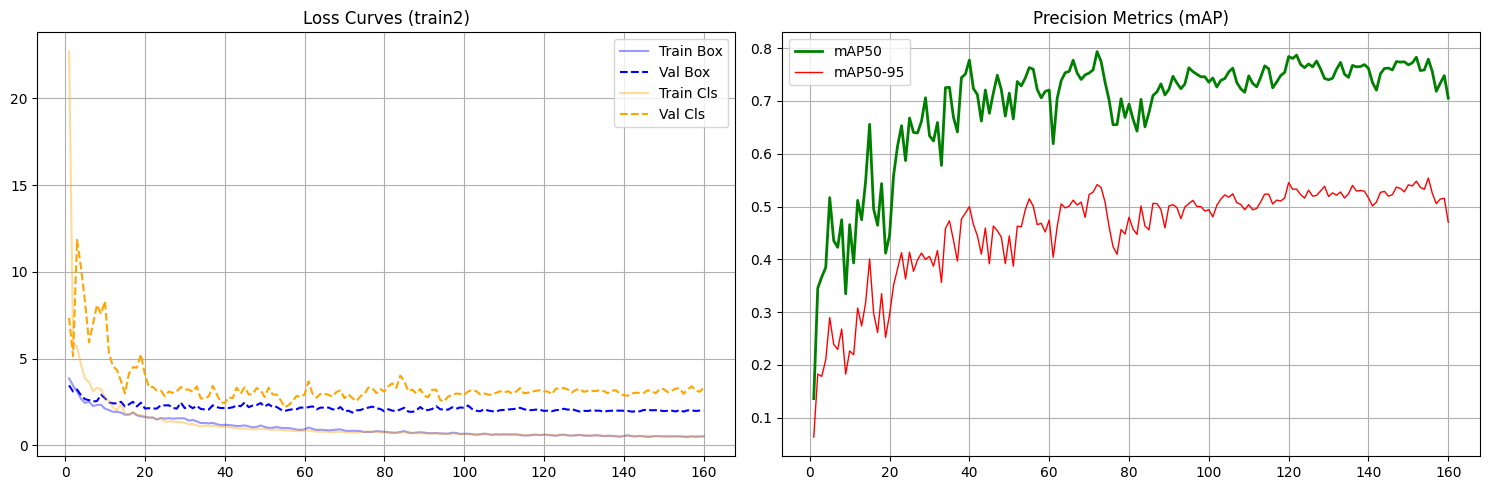

🛑 正在接收停止指令，請稍候...
✅ 監控已安全停止，核心穩定。


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
import glob
import threading
from IPython.display import clear_output, display

# 旗標：控制背景監控是否繼續
keep_running = True

def get_latest_results_csv(base_path="runs/detect/train*/results.csv"):
    files = glob.glob(base_path)
    if not files: return None
    return max(files, key=os.path.getmtime)

def plot_training_results():
    csv_path = get_latest_results_csv()
    if csv_path is None or not os.path.exists(csv_path):
        print(f"⌛ 等待訓練數據產生中...")
        return

    try:
        df = pd.read_csv(csv_path)
        df.columns = [c.strip() for c in df.columns]
    except: return

    if df.empty: return

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # --- Loss 圖 ---
    ax1.plot(df['epoch'], df['train/box_loss'], label='Train Box', color='blue', alpha=0.4)
    ax1.plot(df['epoch'], df['val/box_loss'], label='Val Box', color='blue', linestyle='--')
    ax1.plot(df['epoch'], df['train/cls_loss'], label='Train Cls', color='orange', alpha=0.4)
    ax1.plot(df['epoch'], df['val/cls_loss'], label='Val Cls', color='orange', linestyle='--')
    ax1.set_title(f"Loss Curves ({os.path.basename(os.path.dirname(csv_path))})")
    ax1.legend(); ax1.grid(True)

    # --- mAP 圖 ---
    ax2.plot(df['epoch'], df['metrics/mAP50(B)'], label='mAP50', color='green', linewidth=2)
    ax2.plot(df['epoch'], df['metrics/mAP50-95(B)'], label='mAP50-95', color='red', linewidth=1)
    ax2.set_title("Precision Metrics (mAP)")
    ax2.legend(); ax2.grid(True)

    plt.tight_layout()
    display(fig)
    plt.close()

def monitor_loop():
    """ 背景執行的監控迴圈 """
    global keep_running
    while keep_running:
        clear_output(wait=True)
        print("🟢 監控執行中... (如需停止，請在下方輸入框輸入 'q' 並按 Enter)")
        print(f"最後更新時間: {time.strftime('%H:%M:%S')}")
        plot_training_results()
        # 分段式 sleep，讓停止指令反應更快
        for _ in range(5): 
            if not keep_running: break
            time.sleep(1)

# --- 主程式啟動 ---
if __name__ == "__main__":
    keep_running = True
    
    # 啟動背景執行緒
    thread = threading.Thread(target=monitor_loop)
    thread.start()

    # 主線程等待輸入
    try:
        while True:
            user_cmd = input().strip().lower()
            if user_cmd == 'q':
                print("🛑 正在接收停止指令，請稍候...")
                keep_running = False
                break
    except KeyboardInterrupt:
        keep_running = False

    thread.join()
    print("✅ 監控已安全停止，核心穩定。")